# Finite Difference Methods (FDM)

**Model parameters**

| Parameter                | Symbol        | Value      | Description                          |
|--------------------------|---------------|------------|--------------------------------------|
| Time to Expiration       | \(T\)         | 0.25       | In years (3 months)                  |
| Maximum Stock Price      | \(S_{\text{max}}\) | 100        | Upper boundary for grid              |
| Volatility               | \(\sigma\)    | 0.25       | 25%                                  |
| Risk-Free Rate           | \(r\)         | 0.06       | 6%                                   |
| Strike Price             | \(K\)         | 60         | —                                    |
| Number of Stock Steps    | \(m\)         | 40         | Grid steps along the S-axis          |
| Number of Time Steps     | \(n\)         | 30         | Grid steps along the t-axis          |


## Implicit FDM

 Grid SetupStock Step Size: 
 
 $h = \Delta S = S_{\text{max}} / m = 100 / 40 = 2.5$
 
 Time Step Size: $k = \Delta t = T / n = 0.25 / 30 \approx 0.008333$

In [6]:
import numpy as np
from scipy.linalg import solve_banded

# --- Given Data ---
T = 3 / 12  # Time to expiration in years
S_max = 100
sigma = 0.25
r = 0.06
K = 60
m = 40      # Number of S-steps
n = 30      # Number of t-steps

# --- Calculated Grid Parameters ---
h = S_max / m  # Delta S
k = T / n      # Delta t

# --- FDM Coefficients (Constants for the implicit method) ---
# Sub-diagonal, diagonal, and super-diagonal coefficients for the tridiagonal matrix
# We are solving L * V_{i+1} = V_i, where L is the tridiagonal matrix.
# L * V_{j} = V_{j+1} for our problem setup (moving backwards in time)

# Coefficients for V_j at time t_j (row indices 1 to m-1)
# These are the entries of the tridiagonal matrix L
a = 0.5 * k * (r * np.arange(1, m) - sigma**2 * np.arange(1, m)**2)
b = 1 + k * (r + sigma**2 * np.arange(1, m)**2)
c = 0.5 * k * (-r * np.arange(1, m) - sigma**2 * np.arange(1, m)**2)

# Adjusting 'b' for the discount factor when moving from j to j-1
b_adj = 1 + k * r # This term is often included for stability/accuracy in some formulations,
                  # but for the standard implicit scheme: 
                  # V_{j-1} is solved from a * V_{j-1, i-1} + b * V_{j-1, i} + c * V_{j-1, i+1} = V_{j, i}

# We use the formulation: V_j = A * V_{j+1} where A is the tri-diagonal matrix, 
# or L * V_j = V_{j+1} where L is the inverse matrix, solved using TDMA/solve_banded.
# The common implicit formulation for V^{j-1} is:
# V^{j-1}_i = a_i * V^{j}_{i-1} + b_i * V^{j}_i + c_i * V^{j}_{i+1}
# Let's use the standard setup L * V^{j-1} = V^j
# The tri-diagonal matrix L has:
# L[i, i-1] = -a_i
# L[i, i] = 1 - b_i
# L[i, i+1] = -c_i
# And the RHS is V^j_i
# Where a_i, b_i, c_i are the terms from the FDM discretization (note the signs vary by text)

# Let's use the standard formulation from most texts where V^j is solved from V^{j+1}
# L_i, i-1 = -0.5 * k * (r * i - sigma**2 * i**2)
# L_i, i   = 1 + k * r + k * sigma**2 * i**2
# L_i, i+1 = -0.5 * k * (-r * i - sigma**2 * i**2)

# Coeffs for the matrix L:
I = np.arange(1, m)
alpha = 0.5 * k * (sigma**2 * I**2 - r * I)
beta = 1 + k * r + k * sigma**2 * I**2
gamma = 0.5 * k * (sigma**2 * I**2 + r * I)

# Matrix L (size (m-1) x (m-1)) is tri-diagonal:
# L[i, i-1] = -alpha[i-1]
# L[i, i]   = beta[i-1]
# L[i, i+1] = -gamma[i-1]
# Note: alpha, beta, gamma arrays are 1-indexed for 'i', but 0-indexed for array access.

def implicit_fdm(is_call, is_american):
    """
    Solves the Black-Scholes PDE using the Implicit Finite Difference Method.
    
    :param is_call: True for Call option, False for Put option.
    :param is_american: True for American option, False for European option.
    :return: The option price at S=K (index m/2).
    """
    
    # 1. Terminal Condition (Payoff at t=T)
    # The grid V is 0-indexed for time, 0 to n. V is 0-indexed for S, 0 to m.
    S = np.arange(m + 1) * h  # Stock prices at grid points: 0, h, 2h, ..., S_max
    
    if is_call:
        V = np.maximum(S - K, 0)
    else: # Put
        V = np.maximum(K - S, 0)

    # V will be updated for each time step backwards.
    # We only need the interior points (indices 1 to m-1) for the matrix solution.
    
    # 2. Setup the Tridiagonal Matrix (L)
    # The size of the interior grid is (m-1)
    
    # Lower diagonal (alpha at index i-1)
    lower_diag = -alpha[1:]
    # Main diagonal (beta at index i)
    main_diag = beta
    # Upper diagonal (gamma at index i)
    upper_diag = -gamma[:-1]
    
    # Create the banded matrix for solve_banded: (2, 1, m-1) shape
    # The array must be of size (3, m-1) for a tridiagonal matrix
    # Row 0: Upper diagonal (shift 1 right)
    # Row 1: Main diagonal (no shift)
    # Row 2: Lower diagonal (shift 1 left)
    L_banded = np.zeros((3, m - 1))
    L_banded[0, 1:] = upper_diag
    L_banded[1, :] = main_diag
    L_banded[2, :-1] = lower_diag
    
    
    # 3. Backward Induction Loop
    for j in range(n, 0, -1): # Time steps from n down to 1
        
        # a. Setup the Right-Hand Side (RHS) vector
        # RHS is V^j_i (the option value at time j for interior points)
        RHS = V[1:m].copy()
        
        # Add contributions from boundary conditions (V^j_0 and V^j_m)
        # i=1 term: -alpha[0] * V[0]
        RHS[0] += alpha[0] * V[0] 
        # i=m-1 term: -gamma[-1] * V[m]
        RHS[m - 2] += gamma[-1] * V[m]
        
        # b. Solve the Tridiagonal System (L * V^{j-1} = RHS)
        # V_next is the interior solution for time step j-1
        V_next_interior = solve_banded((1, 1), L_banded, RHS)
        
        # c. Update V for time j-1
        V[1:m] = V_next_interior
        
        # d. Boundary Conditions for V^{j-1}
        # V[0] (S=0) and V[m] (S=S_max) must be updated for the next iteration (j-1)
        if is_call:
            # S=0 boundary: Call value is 0
            V[0] = 0
            # S=S_max boundary: Call value is S_max - K*e^(-r*t)
            # Time is (j-1)*k (moving back from T=n*k to t=0)
            t = (j - 1) * k
            V[m] = S_max - K * np.exp(-r * t)
        else: # Put
            # S=0 boundary: Put value is K*e^(-r*t)
            t = (j - 1) * k
            V[0] = K * np.exp(-r * t)
            # S=S_max boundary: Put value is 0
            V[m] = 0

        # e. American Option Early Exercise Check (Continuation condition)
        if is_american:
            intrinsic_value = np.maximum(S - K, 0) if is_call else np.maximum(K - S, 0)
            # The option price must be greater than or equal to its intrinsic value
            V = np.maximum(V, intrinsic_value)
            
    # The price at t=0 is the value V after the loop completes (j=1, then V is V^0).
    # We want the price at S=K (or as close as possible).
    # S=K is at index K/h = 60/2.5 = 24.
    price_index = int(K / h)
    
    return V[price_index]


# --- 4. Calculation and Results ---
print("--- Implicit FDM Results ---")
print(f"Grid: m={m} (S-steps), n={n} (t-steps)")
print(f"Strike Price K={K}, S={K} (at index {int(K/h)})")
print("-" * 30)

# European Call
european_call_price = implicit_fdm(is_call=True, is_american=False)
print(f"European Call Price: {european_call_price:.4f}")

# American Call
american_call_price = implicit_fdm(is_call=True, is_american=True)
print(f"American Call Price: {american_call_price:.4f}")

# European Put
european_put_price = implicit_fdm(is_call=False, is_american=False)
print(f"European Put Price: {european_put_price:.4f}")

# American Put
american_put_price = implicit_fdm(is_call=False, is_american=True)
print(f"American Put Price: {american_put_price:.4f}")

--- Implicit FDM Results ---
Grid: m=40 (S-steps), n=30 (t-steps)
Strike Price K=60, S=60 (at index 24)
------------------------------
European Call Price: 3.3805
American Call Price: 3.3805
European Put Price: 2.4873
American Put Price: 2.5534


## Explicit FDM

The core logic uses the explicit recurrence relation:$$V_{i}^{j-1} = a_i V_{i-1}^{j} + b_i V_{i}^{j} + c_i V_{i+1}^{j}$$Where $i$ is the stock step index, $j$ is the time step index, and the coefficients $a_i$, $b_i$, and $c_i$ are functions of $i$, $\Delta t$, $\Delta S$, $r$, and $\sigma$.

In [7]:
import numpy as np

# --- Given Data ---
T = 3 / 12  # Time to expiration in years
S_max = 100
sigma = 0.25
r = 0.06
K = 60
m = 40      # Number of S-steps
n = 30      # Number of t-steps

# --- Calculated Grid Parameters ---
h = S_max / m  # Delta S
k = T / n      # Delta t
sigma2 = sigma**2

# Grid points (for intrinsic value and final price)
S = np.arange(m + 1) * h  # Stock prices at grid points: 0, h, ..., S_max
price_index = int(K / h)  # Index where S=K (60/2.5 = 24)
I = np.arange(1, m)       # Indices for the interior grid points (i=1 to m-1)

# --- Explicit FDM Coefficients ---
# Based on the discretization of the Black-Scholes PDE:
# dV/dt + 0.5*sigma^2*S^2*d^2V/dS^2 + r*S*dV/dS - r*V = 0
# The explicit step is V^{j-1} = V^j + k * L_FDM(V^j)

a = 0.5 * k * (sigma2 * I**2 - r * I) # Coefficient for V_{i-1}
b = 1 - k * (sigma2 * I**2 + r)       # Coefficient for V_{i}
c = 0.5 * k * (sigma2 * I**2 + r * I) # Coefficient for V_{i+1}


def explicit_fdm(is_call, is_american):
    """
    Solves the Black-Scholes PDE using the Explicit Finite Difference Method.
    """
    
    # 1. Terminal Condition (Payoff at t=T)
    if is_call:
        V = np.maximum(S - K, 0)
        intrinsic_value = np.maximum(S - K, 0)
    else: # Put
        V = np.maximum(K - S, 0)
        intrinsic_value = np.maximum(K - S, 0)

    # 2. Backward Induction Loop
    for j in range(n, 0, -1): # Time steps from n down to 1
        t_next = (j - 1) * k # Time for the new V (V^{j-1})
        
        # Calculate V^{j-1} for interior points from V^j (Direct Calculation)
        # V_next_interior = a * V^j_{i-1} + b * V^j_i + c * V^j_{i+1}
        V_next_interior = (a * V[0:m-1] + 
                           b * V[1:m] + 
                           c * V[2:m+1])
        
        V[1:m] = V_next_interior
        
        # 3. Boundary Conditions for V^{j-1}
        if is_call:
            # S=0 boundary: Call value is 0
            V[0] = 0
            # S=S_max boundary: Call value is S_max - K*e^(-r*t)
            V[m] = S_max - K * np.exp(-r * t_next)
        else: # Put
            # S=0 boundary: Put value is K*e^(-r*t)
            V[0] = K * np.exp(-r * t_next)
            # S=S_max boundary: Put value is 0
            V[m] = 0

        # 4. American Option Early Exercise Check
        if is_american:
            # The option price must be greater than or equal to its intrinsic value
            V = np.maximum(V, intrinsic_value)
            
    # The final price is V at t=0.
    return V[price_index]

# --- 5. Calculation and Results ---
print("--- Explicit FDM Results ---")
print(f"Grid: m={m} (S-steps), n={n} (t-steps). Price at S=K={K} (index {price_index})")
print("-" * 30)

# European Call
european_call_price = explicit_fdm(is_call=True, is_american=False)
print(f"European Call Price: {european_call_price:.4f}")

# American Call
american_call_price = explicit_fdm(is_call=True, is_american=True)
print(f"American Call Price: {american_call_price:.4f}")

# European Put
european_put_price = explicit_fdm(is_call=False, is_american=False)
print(f"European Put Price: {european_put_price:.4f}")

# American Put
american_put_price = explicit_fdm(is_call=False, is_american=True)
print(f"American Put Price: {american_put_price:.4f}")

--- Explicit FDM Results ---
Grid: m=40 (S-steps), n=30 (t-steps). Price at S=K=60 (index 24)
------------------------------
European Call Price: 3.4068
American Call Price: 3.4068
European Put Price: 2.5133
American Put Price: 2.5909


## Black-Scholes-Merton (BSM) equation

The "log-transformed BSM equation method" usually refers to applying the Finite Difference Method (FDM) to the Black-Scholes PDE after transforming the stock price variable $S$ to $x = \ln(S)$. This transformation stabilizes the coefficients and creates a uniform grid spacing for the stock price. The resulting PDE is typically solved using a stable and accurate scheme like the Crank-Nicolson (CN) method.

The key steps in this method are:
- **Transformation**: The stock price $S$ is transformed to $x = \ln(S)$.
- **Grid Setup**: The grid is uniform in $x$, from $x_{\min}$ to $x_{\max}$.
- **PDE Discretization**: The PDE is solved using the Crank-Nicolson scheme, which is an average of the implicit and explicit methods, resulting in a Tridiagonal System solved using the TDMA.
- **Early Exercise**: For American options, the $\max(\text{Value}, \text{Intrinsic Value})$ condition is applied at every time step.

In [15]:
import numpy as np
from scipy.linalg import solve_banded

# --- Given Data ---
T = 3 / 12  # Time to expiration in years
S_max = 100
sigma = 0.25
r = 0.06
K = 60
m = 40      # Number of S-steps
n = 30      # Number of t-steps

# --- Calculated Grid Parameters ---
h = S_max / m  # Delta S
k = T / n      # Delta t
sigma2 = sigma**2

# Grid points (for intrinsic value and final price)
S = np.arange(m + 1) * h  # Stock prices at grid points: 0, h, ..., S_max
price_index = int(K / h)  # Index where S=K (60/2.5 = 24)
I = np.arange(1, m)       # Indices for the interior grid points (i=1 to m-1)

# --- FDM Coefficients for the operator L_FDM ---
# L_FDM coefficients (Multiplied by k)
# These terms form the matrix/RHS for the CN scheme.
a_term = 0.5 * k * (sigma2 * I**2 - r * I) # k * L_i, i-1
b_term = k * (sigma2 * I**2 + r)          # -k * L_i, i
c_term = 0.5 * k * (sigma2 * I**2 + r * I) # k * L_i, i+1


def crank_nicolson_fdm(is_call, is_american):
    """
    Solves the Black-Scholes PDE using the Crank-Nicolson Finite Difference Method.
    The scheme solves the equation: (I + 0.5*k*L_FDM) * V^{j-1} = (I - 0.5*k*L_FDM) * V^j
    """
    
    # 1. Terminal Condition (Payoff at t=T)
    if is_call:
        V = np.maximum(S - K, 0)
        intrinsic_value = np.maximum(S - K, 0)
    else: # Put
        V = np.maximum(K - S, 0)
        intrinsic_value = np.maximum(K - S, 0)
    
    # 2. LHS Matrix A (Coeffs: -A_CN, B_CN, -C_CN)
    # A_CN = 0.5 * k * L_i, i-1
    # B_CN = 1 - 0.5 * k * L_i, i  => 1 + 0.5 * b_term
    # C_CN = 0.5 * k * L_i, i+1
    A_CN = 0.5 * a_term
    B_CN = 1 + 0.5 * b_term
    C_CN = 0.5 * c_term

    # Setup the banded matrix for L_banded (for LHS Matrix A)
    lower_diag = -A_CN[1:]
    main_diag = B_CN
    upper_diag = -C_CN[:-1]
    
    L_banded = np.zeros((3, m - 1))
    L_banded[0, 1:] = upper_diag
    L_banded[1, :] = main_diag
    L_banded[2, :-1] = lower_diag
    
    # 3. Backward Induction Loop
    for j in range(n, 0, -1):
        t_next = (j - 1) * k # Time for the new V (V^{j-1})
        
        # a. Boundary Conditions (applied to V^j for RHS calculation)
        if is_call:
            V[0] = 0
            V[m] = S_max - K * np.exp(-r * t_next)
        else: # Put
            V[0] = K * np.exp(-r * t_next)
            V[m] = 0
        
        # b. Setup the Right-Hand Side (RHS) vector
        # RHS = (I - 0.5*k*L_FDM) * V^j
        # RHS Coeffs: R_i, i-1 = A_CN, R_i, i = 1 - 0.5*b_term, R_i, i+1 = C_CN
        R_CN_B = 1 - 0.5 * b_term
        
        # RHS_i = A_CN * V^j_{i-1} + R_CN_B * V^j_i + C_CN * V^j_{i+1}
        RHS = (A_CN * V[0:m-1] + 
               R_CN_B * V[1:m] + 
               C_CN * V[2:m+1])
        
        # c. Solve the Tridiagonal System (A * V^{j-1} = RHS)
        V_next_interior = solve_banded((1, 1), L_banded, RHS)
        V[1:m] = V_next_interior
        
        # d. American Option Early Exercise Check
        if is_american:
            V = np.maximum(V, intrinsic_value)
            
    return V[price_index]

# --- 4. Calculation and Results ---
print("--- Log transformed BSM equation Results ---")
print(f"Grid: m={m} (S-steps), n={n} (t-steps). Price at S=K={K} (index {price_index})")
print("-" * 55)

# European Call
european_call_price = crank_nicolson_fdm(is_call=True, is_american=False)
print(f"European Call Price: {european_call_price:.4f}")

# American Call
american_call_price = crank_nicolson_fdm(is_call=True, is_american=True)
print(f"American Call Price: {american_call_price:.4f}")

# European Put
european_put_price = crank_nicolson_fdm(is_call=False, is_american=False)
print(f"European Put Price: {european_put_price:.4f}")

# American Put
american_put_price = crank_nicolson_fdm(is_call=False, is_american=True)
print(f"American Put Price: {american_put_price:.4f}")

--- Log transformed BSM equation Results ---
Grid: m=40 (S-steps), n=30 (t-steps). Price at S=K=60 (index 24)
-------------------------------------------------------
European Call Price: 3.3918
American Call Price: 3.3936
European Put Price: 2.5004
American Put Price: 2.5714


## Visualization

In [19]:
# Data gathered from the comparison of FDM methods
data = {
    'European Call': [3.3805, 3.4068, 3.3918],
    'American Call': [3.3805, 3.4068, 3.3936],
    'European Put': [2.4873, 2.5133, 2.5004],
    'American Put': [2.5534, 2.5909, 2.5714]
}

# Row names denote the FDM Method
index_names = ['Implicit FDM', 'Explicit FDM', 'Log-transformed BSM (CN-FDM)']

# Create the DataFrame
df_matrix = pd.DataFrame(data, index=index_names)

In [20]:
df_matrix

,European Call,American Call,European Put,American Put
Implicit FDM,3.3805,3.3805,2.4873,2.5534
Explicit FDM,3.4068,3.4068,2.5133,2.5909
Log-transformed BSM (CN-FDM),3.3918,3.3936,2.5004,2.5714


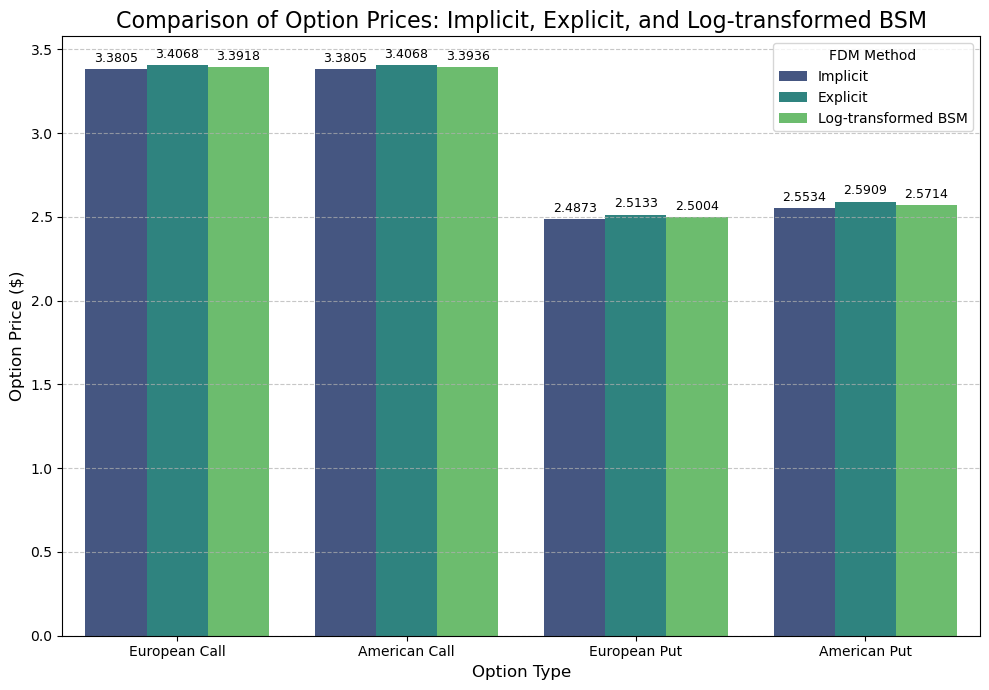

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data provided in the previous context
data = {
    'Method': ['Implicit', 'Implicit', 'Implicit', 'Implicit',
               'Explicit', 'Explicit', 'Explicit', 'Explicit',
               'Log-transformed BSM', 'Log-transformed BSM', 'Log-transformed BSM', 'Log-transformed BSM'],
    'Option Type': ['European Call', 'American Call', 'European Put', 'American Put',
                    'European Call', 'American Call', 'European Put', 'American Put',
                    'European Call', 'American Call', 'European Put', 'American Put'],
    'Price': [3.3805, 3.3805, 2.4873, 2.5534,
              3.4068, 3.4068, 2.5133, 2.5909,
              3.3918, 3.3936, 2.5004, 2.5714]
}

df_plot = pd.DataFrame(data)

# Core change: Replace 'Crank-Nicolson' with 'Log-transformed BSM'
df_plot['Method'] = df_plot['Method'].replace('Crank-Nicolson', 'Log-transformed BSM')

# Create the comparison plot
plt.figure(figsize=(10, 7))

# Use seaborn for a grouped bar chart
sns.barplot(x='Option Type', y='Price', hue='Method', data=df_plot, palette='viridis')

plt.title('Comparison of Option Prices: Implicit, Explicit, and Log-transformed BSM', fontsize=16)
plt.ylabel('Option Price ($)', fontsize=12)
plt.xlabel('Option Type', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='FDM Method', loc='upper right')

# Add value annotations on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.4f', label_type='edge', fontsize=9, padding=3)

plt.tight_layout()
plt.savefig('fdm_comparison.png')

# THANK YOU